### Agrupamiento de desarrolladores de la plataforma Steam

#### Setup inicial

In [135]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


In [329]:
df_reviews = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "andrewmvd/steam-reviews",
    "dataset.csv",
)

In [271]:
df_app_dev = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/application_developers.csv",
)

In [272]:
df_applications = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/applications.csv",
)

c:\Users\Usuario\Documents\Mineria de datos\mineria\Lib\site-packages\kagglehub\pandas_datasets.py:92: DtypeWarning: Columns (0: required_age) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [273]:
df_playtime = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/reviews.csv",
)

### Exploración de datos

In [ ]:
df_playtime_graph = df_playtime[["appid", "author_playtime_forever"]]
df_playtime_graph["author_playtime_forever"] = df_playtime_graph["author_playtime_forever"] / 60
df_game_playtime_graph = df_playtime_graph.groupby("appid")["author_playtime_forever"].agg(
    avg_playtime="mean",
).reset_index()

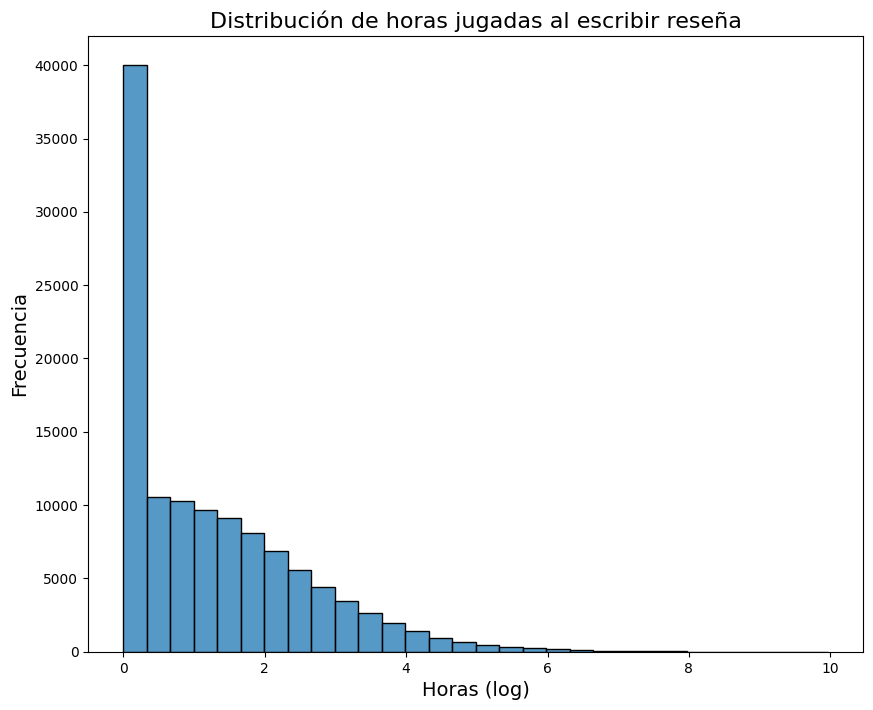

In [299]:
plt.figure(figsize=(10, 8))
sns.histplot(np.log1p(df_game_playtime_graph["avg_playtime"]),
            bins=30,
)
plt.title("Distribución de horas jugadas al escribir reseña", fontsize=16)
plt.xlabel("Horas (log)", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)

plt.show()

In [333]:
df_reviews_graph = df_reviews.copy()
df_reviews_graph.rename(columns={'app_id': 'appid'}, inplace=True)
df_reviews_graph['review_score'] = df_reviews_graph['review_score'].replace(-1, 0)
df_reviews_graph = df_reviews_graph.groupby('appid').agg(
    total_reviews=('appid', 'count'),
    avg_score=('review_score', 'mean'),
).reset_index()

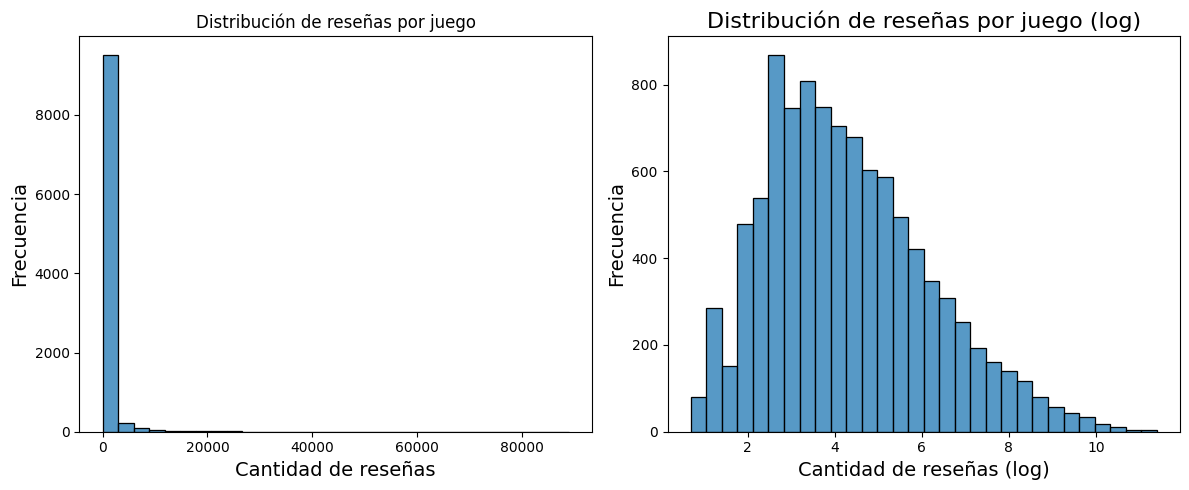

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df_reviews_graph, 
            x="total_reviews", 
            bins=30,
            ax=axes[0])
axes[0].set_title("Distribución de reseñas por juego")
axes[0].set_xlabel("Cantidad de reseñas", fontsize=14)
axes[0].set_ylabel("Frecuencia", fontsize=14)

sns.histplot(np.log1p(df_reviews_graph["total_reviews"]),
            bins=30,
            ax=axes[1])
axes[1].set_title("Distribución de reseñas por juego (log)", fontsize=16)
axes[1].set_xlabel("Cantidad de reseñas (log)", fontsize=14)
axes[1].set_ylabel("Frecuencia", fontsize=14)
plt.tight_layout()

plt.show()

In [335]:
df_reviews_graph.rename(columns={'app_id': 'appid'}, inplace=True)
df_graph = pd.merge(df_game_playtime_graph, df_reviews_graph, on='appid', how='inner')

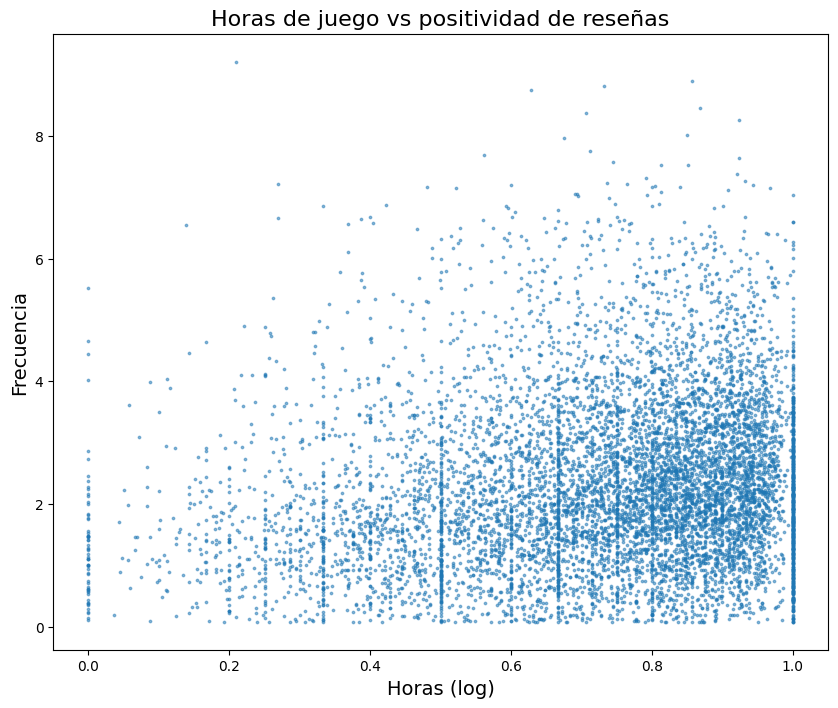

In [336]:
plt.figure(figsize=(10, 8))
plt.scatter(
    df_graph["avg_score"],
    np.log1p(df_graph["avg_playtime"]),
    alpha=0.5,
    s=3,
)
plt.title("Horas de juego vs positividad de reseñas", fontsize=16)
plt.xlabel("Horas (log)", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)

plt.show()

### Preprocesamiento

In [140]:
df_reviews.rename(columns={'app_id': 'appid'}, inplace=True)
df_reviews.drop(columns=["review_text", "review_votes"])
df_reviews['review_score'] = df_reviews['review_score'].replace(-1, 0)

# Agrupar por juego y agregar puntuación promedio
df_reviews = df_reviews.groupby('appid').agg(
    total_reviews=('appid', 'count'),
    avg_score=('review_score', 'mean'),
).reset_index()

# Limitar aplicaciones a juegos
df_applications = df_applications[df_applications["type"] == "game"]


df_playtime = df_playtime[["appid", "author_playtime_forever"]]
df_playtime.rename(columns={'author_playtime_forever': 'playtime_hours'}, inplace=True)

# Minutos a horas
df_playtime["playtime_hours"] = df_playtime["playtime_hours"] / 60

# Agrupar por juego y agregar promedio de horas
df_playtime = df_playtime.groupby("appid")["playtime_hours"].agg(
    avg_playtime="mean",
).reset_index()

In [141]:
df_applications = pd.merge(df_applications, df_app_dev, on='appid', how='inner')

df_applications = pd.merge(df_applications, df_reviews, on='appid', how='inner')

df_applications = pd.merge(df_applications, df_playtime, on='appid', how='inner')

df_applications = df_applications[df_applications['mat_currency'] == 'USD']

df_applications["mat_final_price"] = df_applications["mat_final_price"] / 100

df_developers = df_applications.groupby('developer_id').agg(
    total_games=('appid', 'count'),
    avg_game_score=('avg_score', 'mean'),
    avg_reviews=('total_reviews', 'mean'),
    total_avg_playtime=('avg_playtime', 'mean'),
    avg_price=('mat_final_price', 'mean'),
).reset_index()

In [ ]:
features = [
    'total_games',
    'avg_game_score',
    'avg_reviews',
    'total_avg_playtime',
]

X = df_developers[features]

X['total_games'] = np.log1p(X['total_games'])
X['avg_reviews'] = np.log1p(X['avg_reviews'])
X['total_avg_playtime'] = np.log1p(X['total_avg_playtime'])

X_scaled = StandardScaler().fit_transform(X)

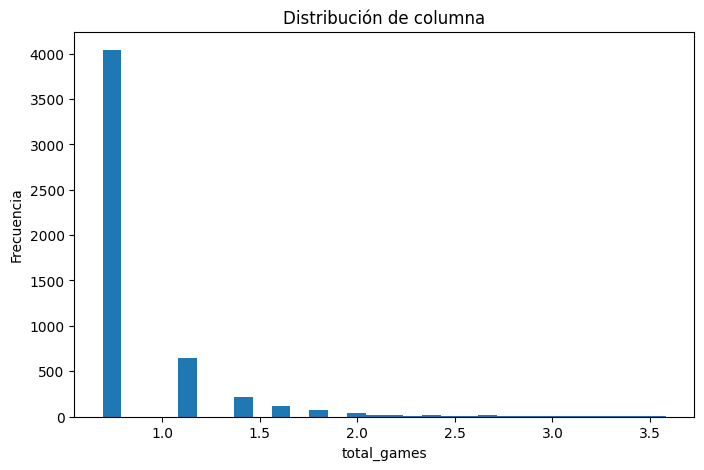

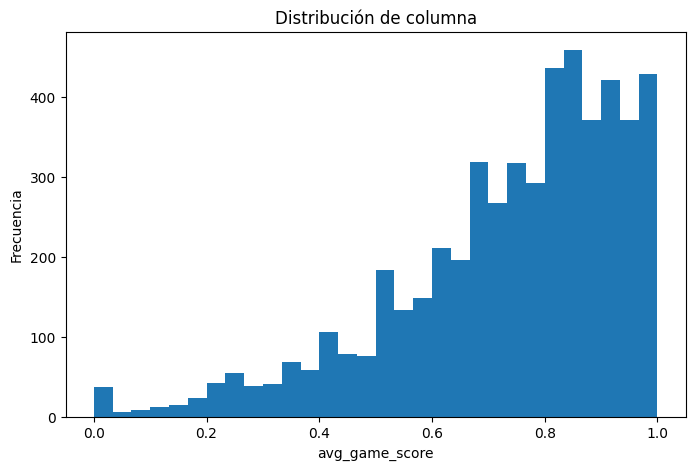

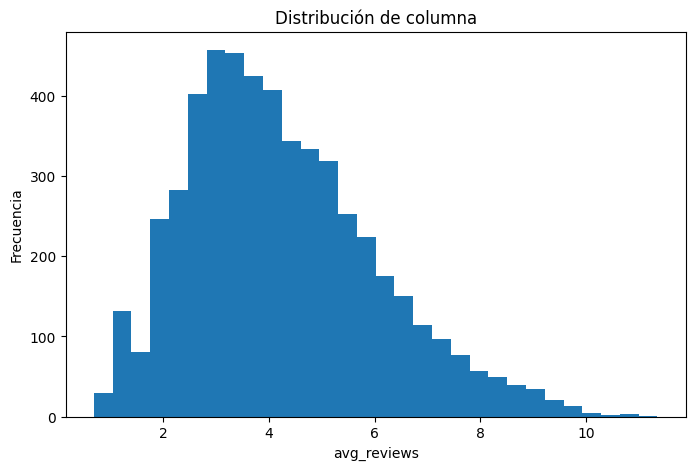

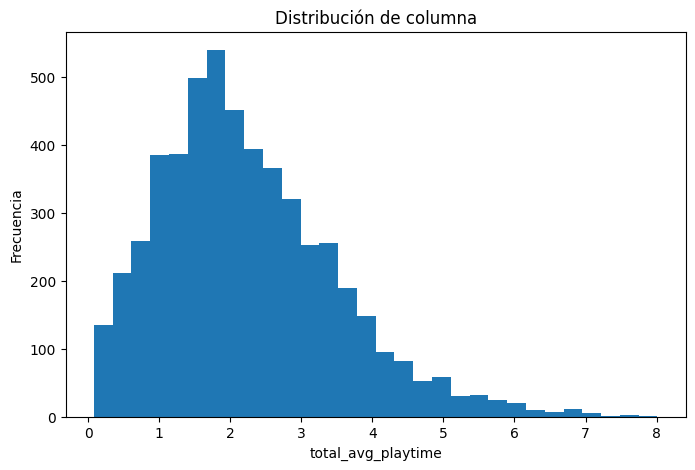

In [267]:
from scipy.stats import skew

for i in features:    
    plt.figure(figsize=(8, 5))

    plt.hist(X[i], bins=30)

    plt.title('Distribución de columna')
    plt.xlabel(f'{i}')
    plt.ylabel('Frecuencia')

    plt.show()


### Modelos

#### K-Means con 3 y 4 clusters

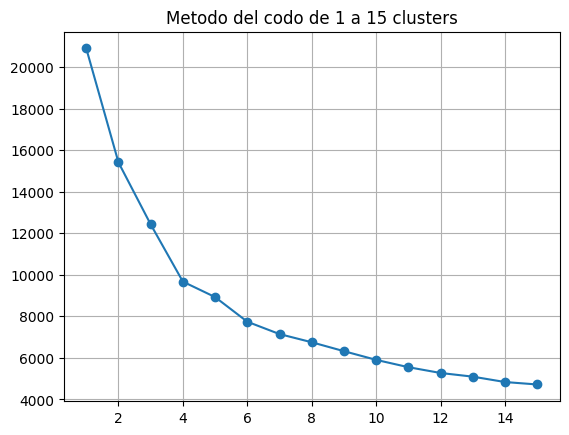

In [156]:
sse = []

clusters = list(range(1, 16))
for k in clusters:
    kmeans = KMeans(n_clusters=k).fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(clusters, sse, marker="o")
plt.title("Metodo del codo de 1 a 15 clusters")
plt.grid(True)
plt.show()

In [233]:
kmeans_3 = KMeans(n_clusters=3, random_state=50).fit(X_scaled)

In [ ]:
kmeans_4 = KMeans(n_clusters=4, random_state=50).fit(X_scaled)

#### Clustering jerárquico con método ward

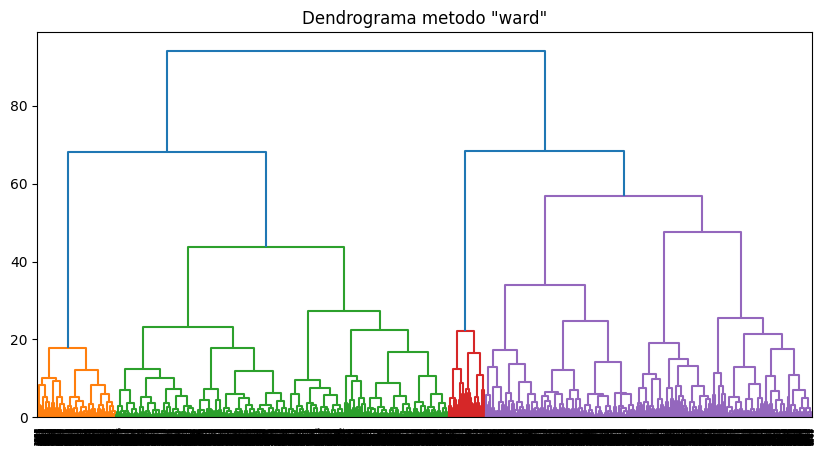

In [160]:
cluster_ward = linkage(X_scaled, 'ward')
fig = plt.figure(figsize=(10, 5))
dendrogram(cluster_ward)
plt.title('Dendrograma metodo "ward"')
plt.show()

In [161]:
ward = AgglomerativeClustering(n_clusters=None,
                                 linkage="ward",
                                 distance_threshold=60).fit(X_scaled)

print("Número de clusters: ", ward.n_clusters_)

Número de clusters:  4


## Evaluación

In [255]:
print("K-Means k = 3\t", silhouette_score(X_scaled, kmeans_3.labels_))
print("K-Means k = 4\t", silhouette_score(X_scaled, kmeans_4.labels_))
print("Ward \t", silhouette_score(X_scaled, ward.labels_))

K-Means k = 3	 0.272185545011226
K-Means k = 4	 0.27816169403985697
Ward 	 0.20204381701974816


In [163]:
from sklearn.metrics.pairwise import cosine_similarity
def sim_matrix(features, model, title):
    labels = model.labels_
    useful_labels = labels >= 0

    indices = np.argsort(labels[useful_labels])
    sorted_features = features[useful_labels][indices]

    d = cosine_similarity(sorted_features, sorted_features)

    plt.figure(figsize=(8, 8))
    im = plt.imshow(d, cmap='plasma', vmin=0.0, vmax=1.0)
    plt.title(title)
    plt.colorbar(im)
    plt.show()

### K-Means con k = 3

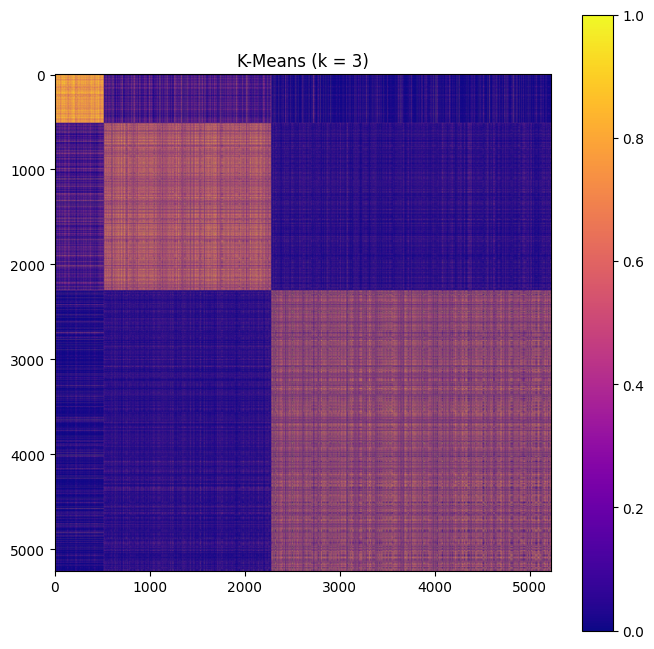

In [263]:
sim_matrix(X_scaled, kmeans_3, "K-Means (k = 3)")

### K-Means con k = 4

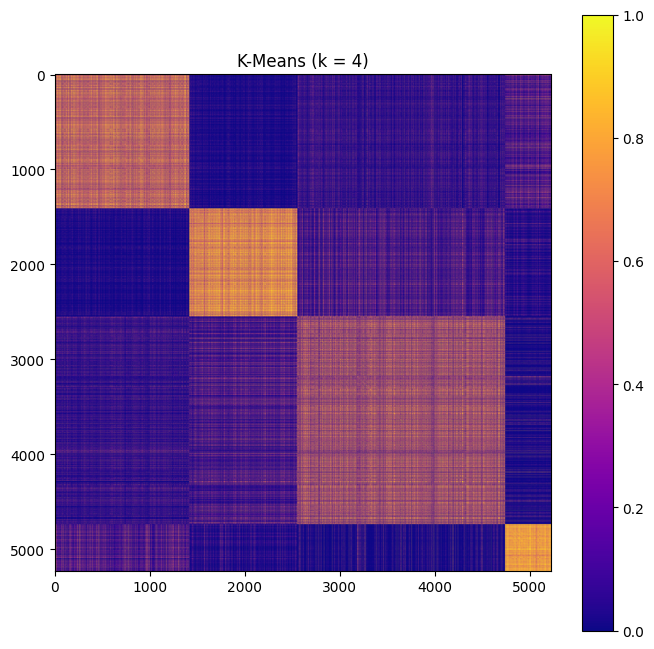

In [264]:
sim_matrix(X_scaled, kmeans_4, "K-Means (k = 4)")

### Clustering jerarquico metodo ward

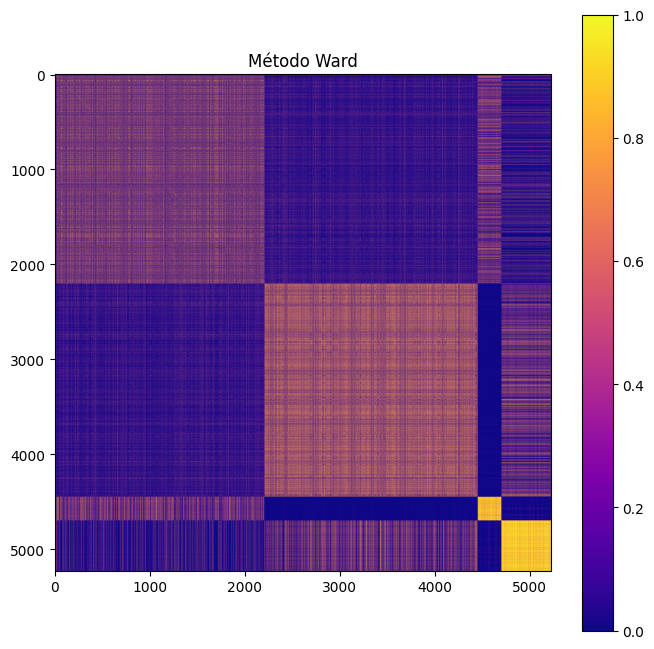

In [265]:
sim_matrix(X_scaled, ward, "Método Ward")

### Atributos por cluster

In [256]:
df_plot = X.copy()
df_plot['cluster'] = kmeans_4.labels_

nombres = {
    0: 'Cluster A',
    1: 'Cluster B',
    2: 'Cluster C',
    3: 'Cluster D',
}

colores = {
    0: 'tab:blue',
    1: 'tab:orange',
    2: 'tab:green',
    3: 'tab:purple'
}

In [258]:
df_plot['total_games'] = np.expm1(df_plot['total_games'])

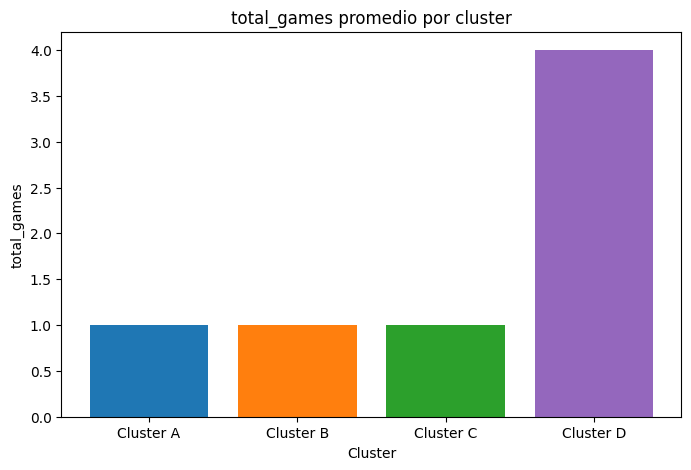

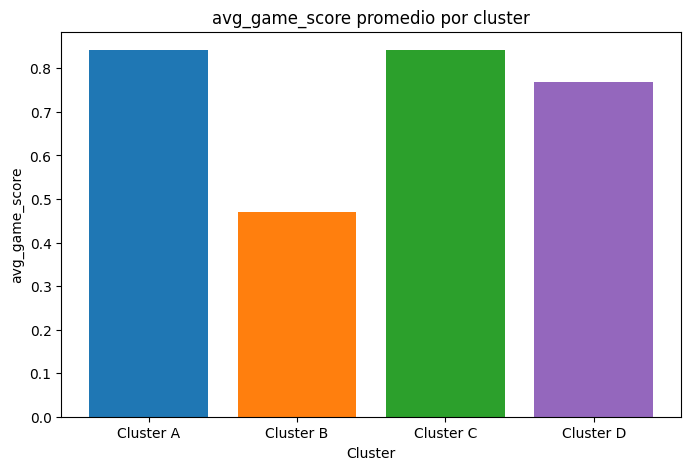

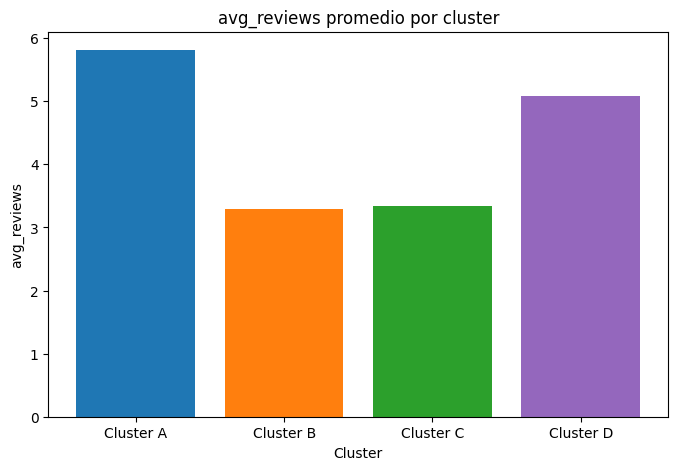

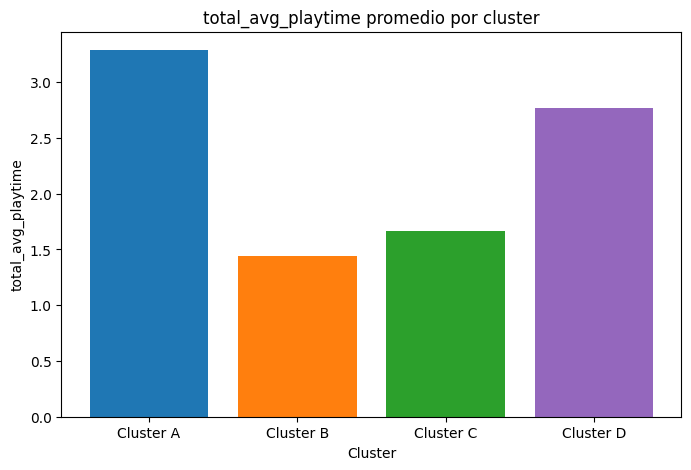

In [259]:
for i in features:
    promedios = df_plot.groupby('cluster')[i].median()

    plt.figure(figsize=(8, 5))

    plt.bar(
        [nombres[c] for c in promedios.index],
        promedios.values,
        color=[colores[c] for c in promedios.index]
    )

    plt.title(f'{i} promedio por cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'{i}')

    plt.show()

## Gráficos de clusters

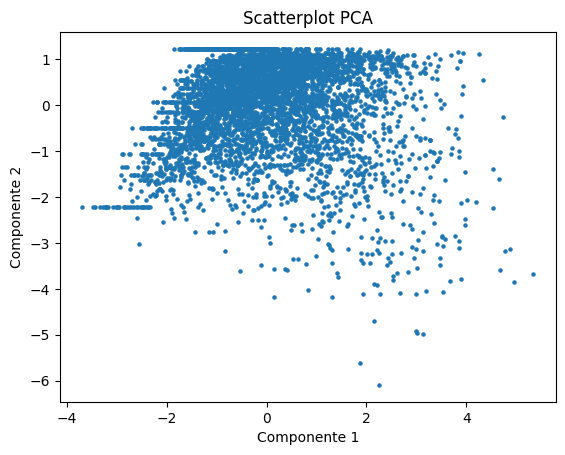

In [260]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_X_pca = pd.DataFrame(X_pca, columns=["C1", "C2"])

plt.scatter(df_X_pca["C1"], df_X_pca["C2"], s=5)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Scatterplot PCA")
plt.show()

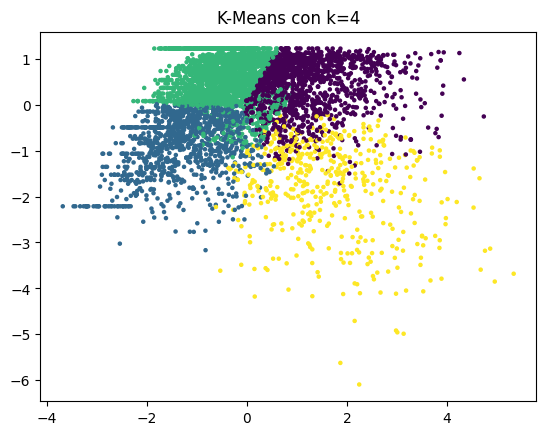

In [262]:
plt.scatter(df_X_pca["C1"], df_X_pca["C2"], s=5, c=kmeans_4.labels_)
plt.title("K-Means con k=4")
plt.show()